# SIR models

This notebook is meant to store my implementations of SIR models and to understand them.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Simple SIR

In [4]:
# Building a simple SIR model using ELFI


def dS(S, I, t, beta, N):

    return -beta*S[t]*I[t]/N[t]

def dI(I, S, t,beta, alpha, N):
    
    return beta*S[t]*I[t]/N[t] - alpha*I[t]

def dR(I, t, alpha):
    
    return alpha*I[t]


def SIR(I0, R0, S0, N, T, beta, alpha, batch_size = 1, random_state = None):
    
    S = [S0]
    I = [I0]
    R = [R0]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]:
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, beta, alpha, N))
        R.append(R[t] + dR(I, t, alpha))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    return S, I, R

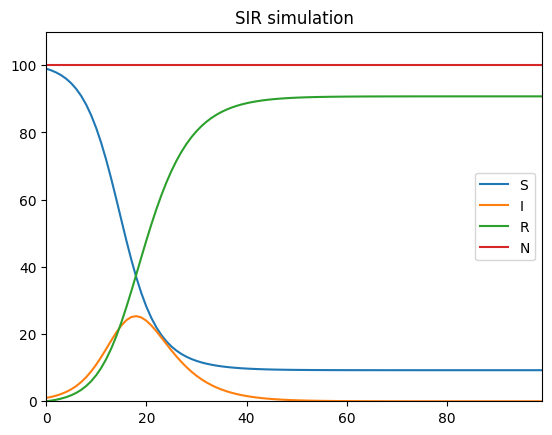

In [10]:
# Visualization of this SIR model

y = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.5, alpha = 0.2)
N = [100]*len(T)
plt.axis([0, max(T), 0, max(N) + 10])

S = y[0]
I = y[1]
R = y[2]

plt.plot(T, S)
plt.plot(T, I)
plt.plot(T, R)
plt.plot(T, N)
plt.title("SIR simulation")
plt.legend(["S", "I", "R", "N"])
plt.show()

Identifiability of $\beta$ and $\alpha$ based only on $I(t)$:

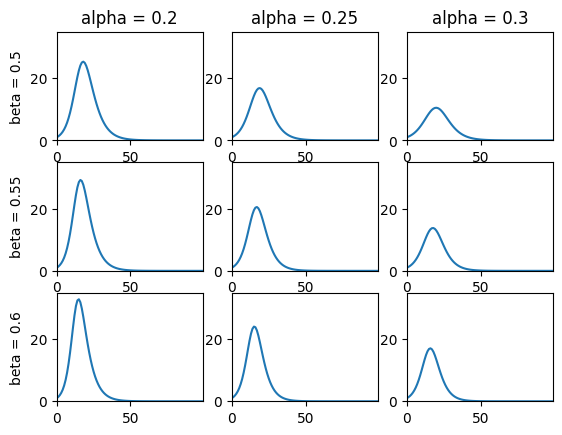

In [5]:
figure, axis = plt.subplots(3, 3)

betas = [0.5, 0.55, 0.6]
alphas = [0.2, 0.25, 0.3]

T = [i for i in range(0,100)] 

for i in range(0, 3):
    
    for j in range(0, 3):
        
        y = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = betas[i], alpha = alphas[j])
        N = [100]*len(T)
        
        
        axis[i, j].plot(T, y[1])
        axis[i,j].set_xlim([0,max(T)])
        axis[i,j].set_ylim([0, 35])
        
        if i == 0:
            axis[i,j].set_title("alpha = " + str(alphas[j]))
        if j == 0:
            axis[i,j].set_ylabel("beta = " + str(betas[i]))

#plt.axis([0, max(T), 0, 30])
plt.show()

# because these are different, then I is enough to identify both parameters alpha and beta.
# (When you think about it, makes perfect sense. If the figures only changed with one of the parameters, then 
# we wouldn't be able to distinguish the other parameter.)

### Least Squares Estimation for a SIR model

In [7]:
# Generate data

T = [i for i in range(0,100)]
SIR_obs = SIR(I0 = 1, R0 = 0, S0 = 999, N = 1000, T=T, beta = 0.5, alpha = 0.2)


In [8]:
# Based on simulated data, what is the value of beta and gamma?

# Basic least squares loss first

def least_squares_estimator(SIR_obs, N, T = 100, plot_loss = False):
    # Simple least squares estimator for calculating beta of a SIR model from data.
    # Assume same initial values as data
    
    I0 = np.ceil(min(SIR_obs[1]))
    R0 = np.ceil(min(SIR_obs[2]))
    S0 = np.ceil(max(SIR_obs[0]))
    
    print("Initial values:", I0, R0, S0)

    T = [i for i in range(0,T)]
    
    S_obs = SIR_obs[0]
    I_obs = SIR_obs[1]
    R_obs = SIR_obs[2]


    alpha = 0.2

    losses = []
    betas = []

    p_test = 0.4 # How much of the observed/simulated distribution is used to calculate the loss
    n_test = int(len(I_obs)*p_test)

    for b in np.arange(0, 2, 0.01): # Iterate over a range of potential values of beta

        new_SIR = SIR(I0, R0, S0, N, T, beta = b, alpha = alpha) # Simulated dataset at the value of beta

        # Compute loss on the number of infected patient
        loss_I = np.sum((np.array(new_SIR[1][0:n_test]) - np.array(I_obs[0:n_test]))**2)
        #loss_S = np.sum((np.array(new_SIR[0]) - np.array(S_obs))**2)
        losses.append(loss_I)
        betas.append(b)


    print("Smallest loss:", np.min(losses))
    print("Achieved at beta =", betas[losses.index(np.min(losses))])
    
    if plot_loss:
        plt.axis([0, max(betas), 0, np.median(losses)])
        plt.plot(betas, losses)
        plt.title("SSE loss vs beta")
        plt.xlabel("beta")
        plt.ylabel("SSE")
        plt.show()
        
        
    #return losses, betas

Initial values: 1.0 0.0 999.0
Smallest loss: 0.0
Achieved at beta = 0.5


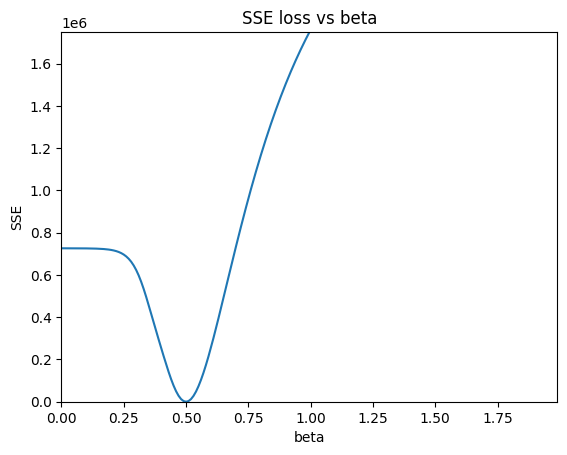

In [9]:
least_squares_estimator(SIR_obs, 1000, plot_loss = True)

# Proportions in a SIR model

In [ ]:
def prop_bsi_a(thetaI, theta_C, theta_BSI, mu_OR, var_OR, OR_size = 1000):
    
    theta_a = np.max(thetaI) # I compartment, here carriage. At maximum, just because - change later.
    theta_0 = theta_C - theta_a
    
    OR_hat = np.random.normal(mu_OR, var_OR, size = OR_size) # get the OR
    
    theta_BSI_a = OR_hat*theta_BSI*theta_a/(theta_0 + OR_hat*theta_a)
    #theta_BSI_a = OR_hat*theta_a/(OR_hat*theta_a + theta_0)
    
    #plt.hist(theta_BSI_a)
    #plt.show()
    
    return np.mean(theta_BSI_a)

def propSIR(beta, gamma, params, bsi_params, is_bsi = False, batch_size = 1, random_state = None):
    # SIR model with proportions
    thetaS = [params["S0"]/params["N"]] # recommendation: make S0 the same as N - I0
    thetaI = [params["I0"]/params["N"]]
    thetaR = [params["R0"]/params["N"]]
    
    #beta = params["beta"]
    #gamma = params["gamma"]
    
    for t in params["times"][:-1]:
        
        dthetaS = -beta*thetaS[t]*thetaI[t]
        dthetaI = beta*thetaS[t]*thetaI[t] - gamma*thetaI[t]
        dthetaR = gamma*thetaI[t]
        
        thetaS.append(thetaS[t] + dthetaS)
        thetaI.append(thetaI[t] + dthetaI)
        thetaR.append(thetaR[t] + dthetaR)
    
    if is_bsi:
        return prop_bsi_a(thetaI, bsi_params["theta_C"], bsi_params["mu_OR"], bsi_params["var_OR"], bsi_params["OR_size"])
    else:
        return thetaS, thetaI, thetaR

bsi_pars = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
params = {"S0": 100000 - 1, "I0": 1, "R0":0, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
pSIR_obs = propSIR(beta = 0.72, gamma = 0.2, params=params, bsi_params=bsi_pars)



In [ ]:
# From this simulated data, calculate the proportion of BSI

bsi_pars = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
params = {"S0": 100000 - 1, "I0": 1, "R0":0, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
pSIR_obs = propSIR(beta = 0.72, gamma = 0.2, params=params, bsi_params=bsi_pars)


T = params["times"] # 1 t = 1 week
plt.plot(T, pSIR_obs[0])
plt.plot(T, pSIR_obs[1])
plt.plot(T, pSIR_obs[2])
plt.title("SIR obs")
plt.ylabel("Fraction of N")
plt.xlabel("t (weeks)")
plt.show()

# TODO: get mu_OR and var_OR from a simulation so that I can use it as "observed data". I need this for the calibration of the model, I think. 
# or is it enough if I try to simulate the SIR directly? It might work, might not. Cutting corners, pretty much.
# ah not possible. I would need an another simulator for that. A BSI simulator!
# From this simulator I would get theta_BSI_A pretty much, then based on that calculate theta_BSI_0.



# repeat many times to check if it is stable
means = []
n_iter = 100
for i in range(0, n_iter):
    means.append(prop_bsi_a(pSIR_obs[1], theta_C = 0.6, theta_BSI=0.05, mu_OR = 0.4, var_OR = 0.6))
    
plt.hist(means) # this is not very stable. What is going on? Poor choice of paramters?
plt.title("Means of theta_BSI_a")
plt.show()

print(np.median(means))

# Observations:
# - as beta increases, so does the theta_BSI_a
# - As the recovery rate gamma increases, theta_BSI_a decreases.
# - at beta = 0.72 and gamma = 0.2 I actually manage to get a decent estimate based on theta_BSI_a from the data.
# What I now actually need to do is "convert" this to ELFI.

# I don't think there is a unique solution to this. 
# I guess there are multiple combinations of gamma and beta that would yield roughly the same theta_BSI_a.

# Question of the day: can I actually use the same data to check and simulate the OR_hats from? Sounds suspicious to me.
# In the sense of using the test set to train the model :)


# Based on those randomly correctly selected beta and gamma, the R0 for ecoli would be:
0.72/0.2 # 3.6. Hypothesis is between 5-10. Note that here I use just some random theta_BSI.